In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import pickle
import sinter
from copy import deepcopy
import scipy

import src.device as device
import src.plotting as plotter
import src.stim_dag as stim_dag

from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.TileCode import TileCode
from src.HGPCode import HGPCode
from src.SHYPSCode import SHYPSCode
from src.RadialCode import RadialCode
from src.GBCode import GBCode
from src.HypercubeCode import HypercubeCode
from src.decoders import BPOSD
from src.constructor import construct_code

In [2]:
compile_tasks = False
if compile_tasks:
    # Making codes
    codes = []
    code_types = []
    code_nkds = []
    code_data_coodes = []

    ds_surface = [3, 5, 7, 9, 11]
    for d in ds_surface:
        code = RotatedSurfaceCode(d)
        codes.append(code)
        code_types.append('Surface')
        code_nkds.append(code.compute_code_parameters())

    nkds_tile = [(288,8,12), (288, 8, 14), (288, 18, 13), (512, 18, 19)]
    for nkd in nkds_tile:
        code = TileCode.known_code(*nkd)
        codes.append(code)
        code_types.append('Tile')
        code_nkds.append(nkd)

    rs_simplex = [3,4]
    for r in rs_simplex:
        code = HGPCode.simplex_code(r)
        codes.append(code)
        code_types.append('Simplex')
        code_nkds.append(code.compute_code_parameters())

    # rs_cube = [2,3]
    # for r in rs_cube:
    #     code = HypercubeCode(r)
    #     codes.append(code)
    #     code_types.append('Hypercube')
    #     code_nkds.append(code.compute_code_parameters())

    lms = [
        (6,6),
        (12,6),
        (12,12),
    ]
    orders = [
        (([3], [1,2]), ([1, 2], [3])),
        (([3], [1, 2]), ([1, 2], [3])),
        (([3], [2, 7]), ([1, 2], [3])),
    ]
    nkds = [
        (72, 12, 6),
        (144, 12, 12),
        (288, 12, 18),
    ]
    for (l,m),(a_ord,b_ord) in zip(lms, orders):
        code = GBCode(l, m, a_ord, b_ord)
        codes.append(code)
        code_types.append('BB')

    code_nkds += nkds

    rsds_radial = [(3,8,12), (3,11,14), (4,6,12), (4,8,16), (4,11,20)]
    for r,s,d in rsds_radial:
        code = RadialCode(r,s,d)
        codes.append(code)
        code_types.append('Radial')
        code_nkds.append(code.compute_code_parameters())

    for code in codes:
        assert len(code.qubit_coords) > 0, code

    code_ids = list(zip(code_types, code_nkds))
else:
    ds_surface = [3, 5, 7, 9, 11]

In [3]:
if compile_tasks:
    hwp = device.default_hwp
    ps_surface = np.geomspace(1e-3, 1e-1, 7)
    # ps_other = np.geomspace(1e-3, 1.5e-3, 5)
    ps_other = np.geomspace(1e-3, 1e-2, 7)
    # p_g = 1e-3
    T2 = 10e-3
    # p = 1e-3
    # t2 = 1e-3
    # p_sh = 1e-3
    # error_params = device.error_params(p=p, T2=t2, p_sh=p_sh)
    buffer = 3
    basis = 'X'
    schedules = dict()
    tasks = []
    for code, code_type, (n,k,d) in zip(codes, code_types, code_nkds):
        print(code_type, f'[[{n}, {k}, {d}]]...')
        xmax,ymax = 0,0
        data_coords = dict()
        for i in code.data_indices:
            x,y = code.qubit_coords[i]
            data_coords[i] = (x+buffer, y+buffer)
            xmax = max(xmax, x)
            ymax = max(ymax, y)
        dev = device.UnitCellDevice(xmax+2*buffer, ymax+2*buffer, hwp)
        
        rounds = d

        if code_type == 'Surface':
            sched = code.get_schedule(hwp, 'Z', rounds=rounds, refocus_shuttling_noise=True)
        else:
            sched = dev.compile_QEC_schedule(
                code,
                data_coords,
                code.check_cx_layers,
                rounds=rounds,
                use_highways=False,
                refocus_shuttle_noise=True,
                separate_X_Z=code_type != 'Surface',
            )
        schedules[(code_type, (n,k,d))] = sched
        
        for p_sh in (ps_surface if code_type == 'Surface' else ps_other):
            p_g = p_sh
            error_params = device.error_params(p=p_g, T2=T2, p_sh=p_sh)
            circ = sched.to_stim_circuit(code, basis, error_params, XYZ_decode=False)
            try:
                circ.detector_error_model()
            except Exception as e:
                print('FAIL', e)

            decoder='pymatching' if code_type == 'Surface' else 'bposd'
            tasks.append(sinter.Task(
                circuit=circ,
                decoder=decoder,
                json_metadata={'n':n, 'k':k, 'd':d, 'type':code_type, 'rounds':rounds, 'basis':basis, 'decoder':decoder, 'p_g':p_g, 'T2':T2, 'p_sh':p_sh},
            ))
    with open('notebooks/data/11_tasks.pkl', 'wb') as f:
        pickle.dump({
            'tasks':tasks,
        }, f)
    with open('notebooks/data/11_params.pkl', 'wb') as f:
        pickle.dump({
            'code_types':code_types,
            'code_nkds':code_nkds,
            'code_data_coodes':code_data_coodes,
            'ps_surface': ps_surface,
            'ps_other': ps_other,
            'schedules':schedules,
        }, f)
else:
    try:
        with open('notebooks/data/11_tasks.pkl', 'rb') as f:
            data = pickle.load(f)
            tasks = data['tasks']
    except FileNotFoundError:
        print('Could not find task file. Setting tasks=None.')
        tasks = None
    with open('notebooks/data/11_params.pkl', 'rb') as f:
        data = pickle.load(f)
        code_types = data['code_types']
        code_nkds = data['code_nkds']
        code_data_coodes = data['code_data_coodes']
        ps_surface = data['ps_surface']
        ps_other = data['ps_other']
        schedules = data['schedules']

In [4]:
code_ids = list(zip(code_types, code_nkds))

In [5]:
stats = sinter.read_stats_from_csv_files('notebooks/data/11_results_TMP')
# with open('notebooks/data/10_results_old_prange.pkl', 'rb') as f:
#     stats = pickle.load(f)
#     stats = [s for s in stats if 'p' in s.json_metadata]

In [6]:
stats

[sinter.TaskStats(strong_id='1c1486fa37e702fa5ea85caa2a64650f529c3463544fe37940f492c1b5e52364', decoder='pymatching', json_metadata={'T2': 0.01, 'basis': 'X', 'd': 3, 'decoder': 'pymatching', 'k': 1, 'n': 9, 'p_g': 0.004641588833612777, 'p_sh': 0.004641588833612777, 'rounds': 3, 'type': 'Surface'}, shots=39185, errors=508, seconds=0.016),
 sinter.TaskStats(strong_id='a23ad824a9cd5af9ac2cf96c6b150ead6f832a4263a5f17dcf513fe43fd47219', decoder='pymatching', json_metadata={'T2': 0.01, 'basis': 'X', 'd': 3, 'decoder': 'pymatching', 'k': 1, 'n': 9, 'p_g': 0.01, 'p_sh': 0.01, 'rounds': 3, 'type': 'Surface'}, shots=9489, errors=509, seconds=0.009999999999999998),
 sinter.TaskStats(strong_id='424ae49fdd4be0a2ac0a6bd060c3dba75ae33bdca44f68c806cf3ce581857daa', decoder='pymatching', json_metadata={'T2': 0.01, 'basis': 'X', 'd': 5, 'decoder': 'pymatching', 'k': 1, 'n': 25, 'p_g': 0.001, 'p_sh': 0.001, 'rounds': 5, 'type': 'Surface'}, shots=5560661, errors=570, seconds=5.455),
 sinter.TaskStats(stro

In [7]:
def logical_fit(p, a, b, c, d):
    return a*(p/b + c)**((d+1)/2)

def fixed_d_logical_fit(d):
    return lambda p,a,b,c: logical_fit(p,a,b,c,d)

p_upper_cutoffs = {
    ('Radial', (352, 18, 20)): 5e-3,
    ('Radial', (256,18,16)): 8e-3,
    ('Radial', (198, 8, 14)): 8e-3,
    ('BB', (288, 12, 18)): 6e-3,
}

fit_params = [(np.nan, np.nan, np.nan, np.nan) for _ in code_ids]
for i,(code_type,(n,k,d)) in enumerate(code_ids):
    ps = []
    lers = []
    uncertainties = []
    for stat in stats:
        if stat.shots == 0:
            continue
        jmd = stat.json_metadata
        if (jmd['type'], jmd['n'], jmd['k'], jmd['d']) == (code_type, n, k, d):
            p_sh = jmd['p_sh']

            cutoff = p_upper_cutoffs.get((code_type,(n,k,d)), float('inf'))
            if p_sh > cutoff:
                continue

            ler = stat.errors / stat.shots
            ler = sinter.shot_error_rate_to_piece_error_rate(ler, pieces=d, values=k)
            unc = np.sqrt(ler * (1 - ler) / stat.shots)
            if 0 < ler:
                if ler > 0.5:
                    ler = 0.5
                    unc = np.sqrt(ler * (1 - ler) / stat.shots)
                ps.append(p_sh)
                lers.append(ler)
                uncertainties.append(unc)
    if len(ps) < 3:
        print('Skipping', code_type, n, k, d, ps, lers)
        continue
    try:
        if code_type in ['Radial', 'BB']:
            bounds=([0, 0, 0, 0], [float('inf'), float('inf'), float('inf'), float('inf')])
            p0 = [0.5, 10, 1, d]
        else:
            bounds=([0, 0, 0, 0], [float('inf'), float('inf'), float('inf'), float('inf')])
            p0=[0.5, 0.1, 0.2, d]

        log_lers = np.log(np.array(lers))
        log_uncertainties = np.array(uncertainties) / np.array(lers)
        fit_params[i] = scipy.optimize.curve_fit(
            lambda p, a, b, c, d: np.log(logical_fit(p, a, b, c, d)), 
            ps, 
            log_lers, 
            sigma=log_uncertainties, 
            p0=p0, 
            bounds=bounds, 
            max_nfev=10000
        )[0]
        # fit_params[i] = scipy.optimize.curve_fit(fixed_d_logical_fit(d), ps, lers, sigma=uncertainties, p0=[1, 1, 0.001])[0]
    except Exception as e:
        print(e)
        continue
    
    print(code_type, n,k,d, fit_params[i], ps, lers, uncertainties)

Surface 9 1 3 [4.81794950e-01 9.02974456e-02 4.96501267e-18 2.25033502e+00] [0.004641588833612777, 0.01, 0.021544346900318832, 0.046415888336127774, 0.1, 0.001, 0.0021544346900318843] [0.0043592776296917934, 0.018560836247849766, 0.06977156222321829, 0.19040389340209057, 0.5, 0.00022839761715992557, 0.00098218448413262] [np.float64(0.0003328117605197559), np.float64(0.001385543733338428), np.float64(0.0044048991385696405), np.float64(0.00814956724398845), np.float64(0.013883533620176643), np.float64(1.614461786263501e-05), np.float64(6.73044686465938e-05)]
Surface 25 1 5 [7.52018227e-02 3.05913148e-02 1.67425057e-16 3.04934078e+00] [0.001, 0.01, 0.021544346900318832, 0.046415888336127774, 0.004641588833612777, 0.1, 0.0021544346900318843] [2.0502841241165637e-05, 0.01743558452103189, 0.09932333616912009, 0.30085441641622795, 0.001929400483864696, 0.20740964191254457, 0.00019824153195102667] [np.float64(1.9201685953552523e-06), np.float64(0.0015173407424940496), np.float64(0.006208297704

/tmp/ipykernel_3139300/2901240841.py:53: OptimizeWarning: Covariance of the parameters could not be estimated
  fit_params[i] = scipy.optimize.curve_fit(


Radial 144 8 12 [2.14445018e+00 1.31411850e-02 1.53289522e-17 5.62570788e+00] [0.001467799267622069, 0.0021544346900318843, 0.0031622776601683794, 0.004641588833612777, 0.006812920690579608, 0.01] [2.083601933933199e-05, 0.00024616337381255793, 0.0063046165091694695, 0.09983563510651883, 0.5, 0.5] [np.float64(3.2276605459395884e-05), np.float64(0.00012700583800335298), np.float64(0.0021353182268729525), np.float64(0.024895433879826352), np.float64(0.05), np.float64(0.05)]
Radial 198 8 14 [1.62340903e-01 5.23835096e-03 1.52730966e-14 6.05215892e+00] [0.0021544346900318843, 0.0031622776601683794, 0.004641588833612777, 0.006812920690579608] [5.736185972715635e-05, 0.011188458863444883, 0.20408426998928653, 0.34079353278297864] [np.float64(0.00010728863295535953), np.float64(0.003998424048598066), np.float64(0.038781663375715106), np.float64(0.04693062263746302)]
Radial 192 18 12 [8.32584266e-02 1.84242056e-03 4.26251332e-19 1.58387635e+00] [0.001, 0.001467799267622069, 0.00215443469003188

[4.81794950e-01 9.02974456e-02 4.96501267e-18 2.25033502e+00]
[7.52018227e-02 3.05913148e-02 1.67425057e-16 3.04934078e+00]
[7.58817019e-02 3.44324962e-02 1.46119364e-18 3.11154163e+00]
[2.62921230e-01 5.88664213e-02 2.77708089e-19 3.11976509e+00]
[3.96895491e-02 1.13959934e-02 3.49212279e-15 2.09152476e+00]
[1.26530535e+01 2.02109250e-02 1.52164560e-34 7.42689258e+00]
[2.31005397e+01 5.22384773e-02 1.93064925e-15 3.21683745e+00]
[9.27833573e+00 3.84803624e-02 5.79902216e-17 2.53784275e+00]
[3.43842297e-01 4.25731719e-03 1.25847707e-13 5.55618158e-01]
[1.32978449e+00 1.46735665e-02 8.54002034e-15 3.61571371e+00]
[2.84184439e+01 5.30046369e-02 4.46714413e-15 3.35612661e+00]
[2.07489259e-01 7.35154749e-03 1.76171289e-23 5.30379429e+00]
[1.15232793e-01 5.39706184e-03 3.48557535e-15 5.67391355e+00]
[2.21492896e-01 4.16663281e-03 5.34163238e-09 1.41598173e+01]
[2.14445018e+00 1.31411850e-02 1.53289522e-17 5.62570788e+00]
[1.62340903e-01 5.23835096e-03 1.52730966e-14 6.05215892e+00]
[8.32584

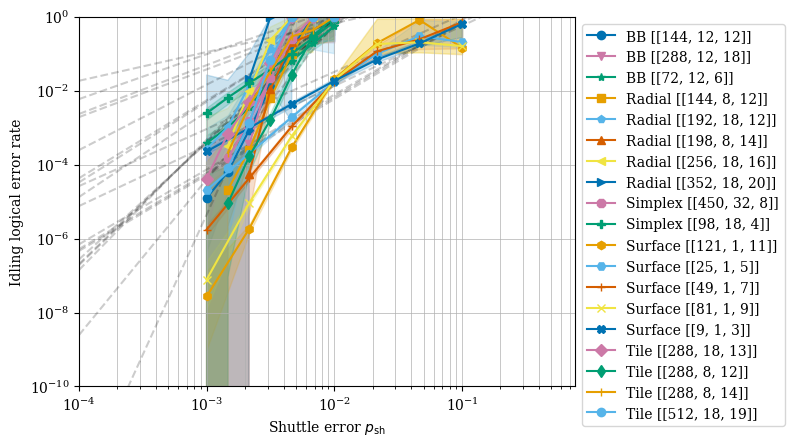

In [8]:
fig,ax = plt.subplots()
# xs_test = np.geomspace(5e-4, 1e-3, 10)
# xs_test_surface = np.geomspace(5e-4, 4e-3, 10)
xs_test = np.geomspace(1e-4, 5e-1, 100)
xs_test_surface = np.geomspace(1e-4, 5e-1, 100)
for fp,code_id in zip(fit_params, code_ids):
    code_type,(n,k,d) = code_id
    print(fp)
    if code_type == 'Surface':
        plt.plot(xs_test_surface, logical_fit(xs_test_surface, *fp), 'k--', alpha=0.2)
    else:
        plt.plot(xs_test, logical_fit(xs_test, *fp), 'k--', alpha=0.2)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p_sh'],
    group_func=lambda s: f"{s.json_metadata['type']} [[{s.json_metadata['n']}, {s.json_metadata['k']}, {s.json_metadata['d']}]]",
    failure_units_per_shot_func=lambda s: s.json_metadata['d'],
    failure_values_func=lambda s: s.json_metadata['k'],
    # highlight_max_likelihood_factor=None,
    filter_func=lambda s: s.json_metadata['p_sh'] < p_upper_cutoffs.get((s.json_metadata['type'], (s.json_metadata['n'], s.json_metadata['k'], s.json_metadata['d'])), float('inf')),
)

# plt.plot(xs_test, logical_fit(xs_test, 0.5, 0.01, 0.2, 10))

plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.loglog()
plt.xlim(1e-4)
plt.ylim(1e-10, top=1)
plt.xlabel('Shuttle error ' + r'$p_\text{sh}$')
plt.ylabel('Idling logical error rate')
ax.grid(which='both', linewidth=0.5)
plt.show()

In [9]:
[s for s in stats if s.json_metadata['type'] == 'BB' and s.json_metadata['n'] == 288]

[sinter.TaskStats(strong_id='e578d5c54a76065df8400410951e5318ca81575c7339105a0a17474e5dc23708', decoder='bposd', json_metadata={'T2': 0.01, 'basis': 'X', 'd': 18, 'decoder': 'bposd', 'k': 12, 'n': 288, 'p_g': 0.001, 'p_sh': 0.001, 'rounds': 18, 'type': 'BB'}, shots=1556, seconds=14014.560000000003),
 sinter.TaskStats(strong_id='e1cdf56af427c1c1e49e7a89c269b00bcca5ad3fd6daa7abe981af63449d9d78', decoder='bposd', json_metadata={'T2': 0.01, 'basis': 'X', 'd': 18, 'decoder': 'bposd', 'k': 12, 'n': 288, 'p_g': 0.001467799267622069, 'p_sh': 0.001467799267622069, 'rounds': 18, 'type': 'BB'}, shots=1419, seconds=14005.509999999995),
 sinter.TaskStats(strong_id='13b34cee9314c68d0966265a77282eac654e3ec533484cb1449140aa6a3c7138', decoder='bposd', json_metadata={'T2': 0.01, 'basis': 'X', 'd': 18, 'decoder': 'bposd', 'k': 12, 'n': 288, 'p_g': 0.0021544346900318843, 'p_sh': 0.0021544346900318843, 'rounds': 18, 'type': 'BB'}, shots=790, errors=5, seconds=14058.900000000003),
 sinter.TaskStats(strong_i

In [10]:
fit_params[code_ids.index(('BB', (288,12,18)))]

array([2.21492896e-01, 4.16663281e-03, 5.34163238e-09, 1.41598173e+01])

Surface (9, 1, 3) (111.1111111111111, np.float64(7.575207124187202e-06))
Surface (25, 1, 5) (40.0, np.float64(6.977685730853027e-07))
Surface (49, 1, 7) (20.408163265306122, np.float64(4.620736879949741e-07))
Surface (81, 1, 9) (12.345679012345679, np.float64(5.178734751442321e-07))
Surface (121, 1, 11) (8.264462809917356, np.float64(2.626793935655598e-05))
Tile (288, 8, 12) (27.777777777777775, np.float64(2.4419218766325166e-09))
Tile (288, 8, 14) (27.777777777777775, np.float64(4.294969032082463e-05))
Tile (288, 18, 13) (62.5, np.float64(0.0002479620906365509))
Tile (512, 18, 19) (35.15625, np.float64(0.018586709953911318))
Simplex (98, 18, 4) (183.67346938775512, np.float64(1.3296184423702614e-05))
Simplex (450, 32, 8) (71.11111111111111, np.float64(3.3103372457566685e-05))
BB (72, 12, 6) (166.66666666666666, np.float64(2.7187026312491424e-07))
BB (144, 12, 12) (83.33333333333333, np.float64(1.9117968360600065e-07))
BB (288, 12, 18) (41.666666666666664, np.float64(1.168251777621318e

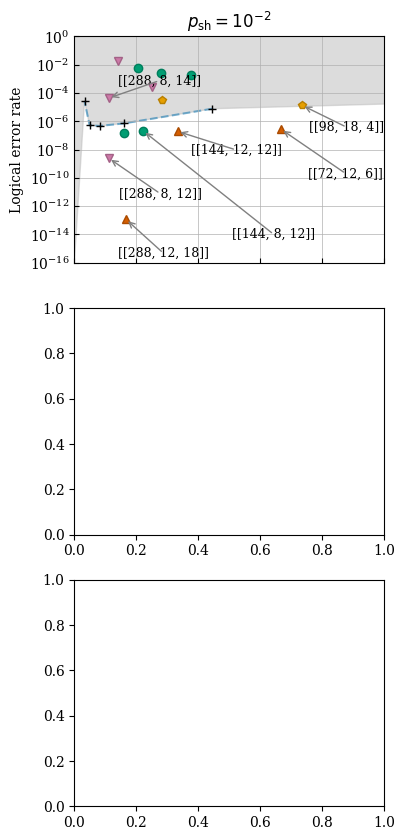

In [12]:
from adjustText import adjust_text

label_all = False
label_codes = [
    ('Simplex', (98,18,4)),
    ('BB', (72,12,6)),
    ('BB', (144,12,12)),
    ('BB', (288,12,18)),
    # ('Radial', (256,18,16)),
    # ('Radial', (198,8,14)),
    ('Radial', (144,8,12)),
    # ('Radial', (192,18,12)),
    ('Tile', (288,8,14)),
    ('Tile', (288,8,12)),
]

markerdict = {
    'Surface':'+',
    'BB':'^',
    'Radial':'o',
    'Simplex':'p',
    'Tile':'v',
    'Hypercube':'s',
}
colordict = {
    'Surface':'k',
    'BB':'C5',
    'Radial':'C2',
    'Simplex':'C3',
    'Tile':'C1',
    'Hypercube':'C0'
}

ps_display = [
    r'10^{-2}',
    r'3 \times 10^{-3}',
    r'10^{-3}',
]

skip = ['Hypercube']
# skip = []

fig,ax = plt.subplots(3,1,figsize=(4,10))
fig.subplots_adjust(hspace=0.2)
for j,p_tgt in enumerate([1e-4]):
    T2_tgt = 10**(-6-np.log10(p_tgt))
    p_sh_tgt = p_tgt

    points = [(np.nan, np.nan) for _ in code_ids]
    texts = []
    for i,(code_type, (n,k,d)) in enumerate(code_ids):
        if code_type in skip:
            continue
        if np.all(np.isfinite(fit_params[i])):
            ler_proj = logical_fit(p_tgt, *fit_params[i])
            enc_rate = k / n
            points[i] = (enc_rate*1000, ler_proj)
            ax[j].plot(*points[i], marker=markerdict[code_type], color=colordict[code_type], markeredgecolor=plotter.interpolate(colordict[code_type], 'k', 0.2))
            if label_all or (code_type, (n,k,d)) in label_codes:
                texts.append(ax[j].text(*points[i], f'[[{n}, {k}, {d}]]', fontsize=9, ha='left', va='top'))
            print(code_type, (n,k,d), points[i])
    xs_surface = []
    ys_surface = []
    for d in ds_surface:
        pt = points[code_ids.index(('Surface', (d**2,1,d)))]
        xs_surface.append(pt[0])
        ys_surface.append(pt[1])
    ax[j].plot(xs_surface, ys_surface, 'C0--', alpha=0.5, zorder=0.2)
    ax[j].set_yscale('log')

    ax[j].set_xlim(0, 250)
    ax[j].set_ylim(top=1)
    xlim = ax[j].get_xlim()
    ylim = ax[j].get_ylim()

    xs_surface = np.array([-10] + xs_surface + [1000])
    ys_surface = np.array([1e-30] + ys_surface + [1e-3])
    sort_idx = np.argsort(xs_surface)
    ax[j].fill_between(xs_surface[sort_idx], ys_surface[sort_idx], [1]*len(ys_surface), color='#BBBBBB', zorder=0, alpha=0.5)

    ax[j].set_xlim(*xlim)
    ax[j].set_ylim(*ylim)

    for (code_type, marker) in markerdict.items():
        if code_type in skip:
            continue
        ax[j].plot([], [], color=colordict[code_type], marker=marker, linestyle='none', markeredgecolor=plotter.interpolate(colordict[code_type], 'k', 0.2), label=code_type)
    if j == 1:
        ax[j].legend(bbox_to_anchor=(0.8,0.2), loc='center')

    
    ax[j].set_title(r'$p_\text{sh}=' + ps_display[j] + r'$')
    if j == 2:
        ax[j].set_xlabel('# logical qubits per 1000 physical qubits')
    else:
        ax[j].set_xticklabels([])
    ax[j].set_ylabel('Logical error rate')
    # ax[j].ylim(1e-18, 1e-2)
    ax[j].set_yticks(ax[j].get_yticks(), minor=[])
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray'),
        # force_text=(1, 1),
        force_static=(1, 1),
        expand=(1.2, 3),
        prevent_crossings=True,
        add_objects=ax[j].collections,
        ax=ax[j],
    )
    ax[j].grid(which='both', linewidth=0.5, zorder=0.1)
    ax[j].tick_params(direction='in', which='both')
    ax[j].set_ylim(top=1)
plt.savefig('notebooks/fig/10_encoding_rate.pdf', bbox_inches='tight')
plt.savefig('notebooks/fig/10_encoding_rate.svg', bbox_inches='tight')
plt.show()

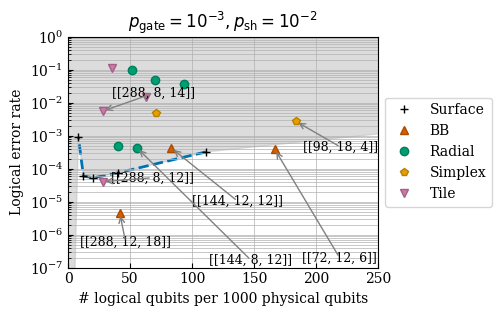

In [13]:
from adjustText import adjust_text

label_all = False

ps_display = [
    r'10^{-2}',
    r'3 \times 10^{-3}',
    r'10^{-3}',
]

for j,p_tgt in enumerate([1e-3]):
    fig,ax = plt.subplots(figsize=(4,3))
    T2_tgt = 10**(-6-np.log10(p_tgt))
    p_sh_tgt = p_tgt

    points = [(np.nan, np.nan) for _ in code_ids]
    texts = []
    for i,(code_type, (n,k,d)) in enumerate(code_ids):
        if code_type in skip:
            continue
        if np.all(np.isfinite(fit_params[i])):
            ler_proj = logical_fit(p_tgt, *fit_params[i])
            enc_rate = k / n
            points[i] = (enc_rate*1000, ler_proj)
            ax.plot(*points[i], marker=markerdict[code_type], color=colordict[code_type], markeredgecolor=plotter.interpolate(colordict[code_type], 'k', 0.2))
            if label_all or (code_type, (n,k,d)) in label_codes:
                texts.append(ax.text(*points[i], f'[[{n}, {k}, {d}]]', fontsize=9, ha='left', va='top'))
    xs_surface = []
    ys_surface = []
    for d in ds_surface:
        pt = points[code_ids.index(('Surface', (d**2,1,d)))]
        xs_surface.append(pt[0])
        ys_surface.append(pt[1])
    ax.plot(xs_surface, ys_surface, 'C0--', alpha=1, zorder=0.2, linewidth=2)
    ax.set_yscale('log')

    ax.set_xlim(0, 250)
    ax.set_ylim(top=1)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xs_surface = np.array([-10] + xs_surface + [1000])
    ys_surface = np.array([1e-30] + ys_surface + [1])
    sort_idx = np.argsort(xs_surface)
    ax.fill_between(xs_surface[sort_idx], ys_surface[sort_idx], [1]*len(ys_surface), color='#BBBBBB', zorder=0, alpha=0.5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    for (code_type, marker) in markerdict.items():
        if code_type in skip:
            continue
        ax.plot([], [], color=colordict[code_type], marker=marker, linestyle='none', markeredgecolor=plotter.interpolate(colordict[code_type], 'k', 0.2), label=code_type)

    ax.legend(bbox_to_anchor=(1,0.5), loc='center left')
    
    # ax.set_title(r'$(p,T_2,p_\text{sh})=(' + ps_display[j] + f', {T2_tgt*1e3:.2g}ms, ' + ps_display[j] + r')$')
    ax.set_title(r'$p_\text{gate} = 10^{-3}, p_\text{sh}=' + ps_display[j] + r'$')
    ax.set_xlabel('# logical qubits per 1000 physical qubits')

    ax.set_ylabel('Logical error rate')
    # ax.ylim(1e-18, 1e-2)
    ax.set_yticks(ax.get_yticks(), minor=[])
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray'),
        # force_text=(1, 1),
        force_static=(1, 3),
        expand=(1.2, 4),
        prevent_crossings=True,
        add_objects=ax.collections,
        ax=ax,
    )
    ax.grid(which='both', linewidth=0.5, zorder=0.1)
    ax.tick_params(direction='in', which='both')
    ax.set_ylim(top=1)
    plt.savefig(f'notebooks/fig/10_encoding_rate_{j}.pdf', bbox_inches='tight')
    plt.savefig(f'notebooks/fig/10_encoding_rate_{j}.png', dpi=300, bbox_inches='tight')
    # plt.savefig('notebooks/fig/10_encoding_rate.svg', bbox_inches='tight')
    plt.show()

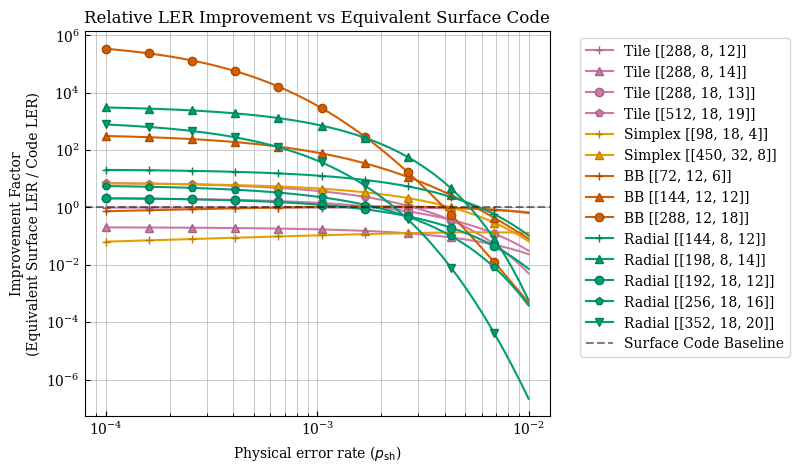

In [13]:
from scipy.interpolate import interp1d

# Define the range of physical error rates to plot
ps_eval = np.geomspace(1e-4, 1e-2, 50)

fig, ax = plt.subplots(figsize=(6, 5))

# Extract surface code fit parameters
surface_data = []
for d in ds_surface:
    idx = code_ids.index(('Surface', (d**2, 1, d)))
    fp = fit_params[idx]
    surface_data.append((1 / (d**2), fp))

markerlist = [
    '+',
    '^',
    'o',
    'p',
    'v',
    's',
]
type_counts = dict()

# Calculate and plot the improvement factor for each non-Surface code
for i, (code_type, (n, k, d)) in enumerate(code_ids):
    if code_type == 'Surface' or code_type in skip:
        continue
    
    fp_code = fit_params[i]
    if not np.all(np.isfinite(fp_code)):
        continue

    encoding_rate = k / n
    improvements = []

    for p in ps_eval:
        # 1. Evaluate surface code LERs at this specific physical error rate (p)
        sc_rates = []
        sc_lers = []
        for sc_rate, sc_fp in surface_data:
            sc_rates.append(sc_rate)
            sc_lers.append(logical_fit(p, *sc_fp))
            
        # Append the bare physical qubit representing an encoding rate of 1
        sc_rates.append(1.0)
        sc_lers.append(p)
        
        # Sort values to ensure interp1d works correctly
        sort_idx = np.argsort(sc_rates)
        sc_rates = np.array(sc_rates)[sort_idx]
        sc_lers = np.array(sc_lers)[sort_idx]
        
        # 2. Create interpolation function in log-log space
        interp_func = interp1d(
            np.log10(sc_rates), 
            np.log10(sc_lers), 
            kind='linear',
            bounds_error=False, 
            fill_value='extrapolate' # Handles codes with k/n < 1/121
        )
        
        # 3. Find the Equivalent Surface Code LER
        equiv_sc_ler = 10**(interp_func(np.log10(encoding_rate)))
        
        # 4. Find the actual code LER and calculate the ratio (Speedup)
        code_ler = logical_fit(p, *fp_code)
        improvement = equiv_sc_ler / code_ler
        improvements.append(improvement)

    # Plot the results
    ax.plot(
        ps_eval, 
        improvements, 
        label=f'{code_type} [[{n}, {k}, {d}]]',
        color=colordict.get(code_type, 'k'),
        marker=markerlist[type_counts.get(code_type, 0)],
        markevery=5, # Spacing out markers so they don't clutter the line
        markeredgecolor=plotter.interpolate(colordict.get(code_type, 'k'), 'k', 0.2)
    )
    type_counts[code_type] = type_counts.get(code_type, 0) + 1

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Physical error rate ($p_{\text{sh}}$)')
ax.set_ylabel('Improvement Factor\n(Equivalent Surface LER / Code LER)')

# Add a baseline indicating "no improvement" over surface codes
ax.axhline(1, color='k', linestyle='--', alpha=0.5, label='Surface Code Baseline')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(which='both', linewidth=0.5, zorder=0.1)
ax.tick_params(direction='in', which='both')

plt.title('Relative LER Improvement vs Equivalent Surface Code')
# plt.savefig('notebooks/fig/10_improvement_factor.pdf', bbox_inches='tight')
plt.show()